# Oxford Battery Degradation Dataset 1 — Download, Parse, and Pseudo-OCV Extraction

**Manuscript:** *Aging-Driven Open-Circuit Voltage Deformation Across Lithium-Ion Battery Datasets: Transferable Descriptors for Health-Aware Battery Management*

**Authors:** Sevgi Erzen, Coskun Fırat — Istanbul Technical University

This notebook downloads the Oxford Battery Degradation Dataset 1 (Birkl & Howey, 2017), parses the per-cell aging characterization, extracts pseudo-OCV(SOC) **discharge** curves at each aging state, computes the SOH trajectory from capacity fade, and writes cleaned outputs to Parquet for the §4 Results descriptor analysis.

**Dataset:**
- Birkl, C. (2017). *Oxford Battery Degradation Dataset 1.* University of Oxford.
- 8 × Kokam SLPB533459H4 pouch cells (nominal 740 mAh)
- 40 °C cycling with periodic C/25 pseudo-OCV characterization (~every 100 cycles)

**Preprocessing protocol** (consistent with Paper 1 / manuscript §3.1):
- Discharge-branch selection
- Voltage range clip + rolling-median MAD outlier rejection
- SOC reconstruction: $SOC = 1 - (Q_d - Q_{d,\min})/(Q_{d,\max} - Q_{d,\min})$
- Savitzky–Golay smoothing (adaptive window, order 3)
- PCHIP interpolation onto common SOC grid (0.01 → 0.99, 99 points)
- SOH = $Q_\text{aged} / Q_\text{initial}$


## 0. Environment setup

In [ ]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import PchipInterpolator

# IBM colorblind-safe palette (consistent with Paper 1 figures)
IBM = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000',
       '#009E73', '#56B4E9', '#000000']

plt.rcParams.update({
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
})

print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"Python  : {sys.version.split()[0]}")

NumPy   : 2.0.2
Pandas  : 2.2.2
Python  : 3.12.13


## 1. Mount Drive and configure paths

The default path follows the layout used in Paper 1 (`Colab Notebooks/Battery Data/`). Adjust `DRIVE_ROOT` if your folder layout differs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/Battery Data')
OXFORD_DIR = DRIVE_ROOT / 'Oxford Battery Degradation Dataset 1'
OUTPUT_DIR = OXFORD_DIR / 'processed'
FIGURE_DIR = OXFORD_DIR / 'figures'

for d in (OXFORD_DIR, OUTPUT_DIR, FIGURE_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Oxford raw     : {OXFORD_DIR}")
print(f"Processed out  : {OUTPUT_DIR}")
print(f"Figures out    : {FIGURE_DIR}")
print()
print("Current contents of OXFORD_DIR:")
for p in sorted(OXFORD_DIR.iterdir()):
    size = p.stat().st_size / 1e6 if p.is_file() else 0
    tag = f' ({size:.1f} MB)' if p.is_file() else '/'
    print(f"  {p.name}{tag}")

Mounted at /content/drive
Oxford raw     : /content/drive/MyDrive/Colab Notebooks/Battery Data/Oxford Battery Degradation Dataset 1
Processed out  : /content/drive/MyDrive/Colab Notebooks/Battery Data/Oxford Battery Degradation Dataset 1/processed
Figures out    : /content/drive/MyDrive/Colab Notebooks/Battery Data/Oxford Battery Degradation Dataset 1/figures

Current contents of OXFORD_DIR:
  Capacity_Fade_Cell8.csv (0.0 MB)
  DPhil_thesis_Christoph_Birkl_final_submission.pdf (49.8 MB)
  ExampleDC_C1.mat (0.1 MB)
  Oxford_Battery_Degradation_Dataset_1.mat (266.2 MB)
  Readme.txt (0.0 MB)
  figures/
  processed/


## 2. Verify dataset files

The dataset is already in `OXFORD_DIR`. Expected contents:

| File | Purpose |
|------|---------|
| `Oxford_Battery_Degradation_Dataset_1.mat` | main dataset — used in §3 onward |
| `Capacity_Fade_Cell8.csv`                  | independent capacity-fade table — used for §5 cross-check |
| `ExampleDC_C1.mat`                         | example single-cell file — not used here |
| `DPhil_thesis_Christoph_Birkl_final_submission.pdf` | reference documentation |
| `Readme.txt`                               | dataset documentation |

In [ ]:
OXFORD_MAT_NAME = "Oxford_Battery_Degradation_Dataset_1.mat"
CAP_FADE_CELL8  = "Capacity_Fade_Cell8.csv"

target = OXFORD_DIR / OXFORD_MAT_NAME
cap_csv_path = OXFORD_DIR / CAP_FADE_CELL8

assert target.exists(), f"Main .mat file not found at: {target}"
print(f"✓ {target.name:50s} {target.stat().st_size / 1e6:7.1f} MB")

if cap_csv_path.exists():
    print(f"✓ {cap_csv_path.name:50s} {cap_csv_path.stat().st_size / 1024:7.1f} KB  "
          f"(will be used for §5 cross-validation)")
else:
    print(f"⚠ {CAP_FADE_CELL8} not found — §5 cross-check will be skipped.")

✓ Oxford_Battery_Degradation_Dataset_1.mat             266.2 MB
✓ Capacity_Fade_Cell8.csv                                1.8 KB  (will be used for §5 cross-validation)


## 3. Load the `.mat` file

Oxford v1 is typically MATLAB v5/v7 (scipy-compatible). If a re-saved v7.3 (HDF5) variant is encountered, the loader falls back to `mat73`.

In [ ]:
def load_oxford_mat(path):
    """Robust loader: scipy first, mat73 fallback for v7.3 (HDF5) files."""
    try:
        from scipy.io import loadmat
        data = loadmat(str(path), struct_as_record=False, squeeze_me=True)
        return {k: v for k, v in data.items() if not k.startswith('__')}, 'scipy'
    except NotImplementedError:
        try:
            import mat73
        except ImportError:
            !pip install -q mat73
            import mat73
        return mat73.loadmat(str(path)), 'mat73'

mat_path = OXFORD_DIR / OXFORD_MAT_NAME
raw, backend = load_oxford_mat(mat_path)

print(f"Loaded with backend : {backend}")
print(f"Top-level keys      : {list(raw.keys())}")

Loaded with backend : scipy
Top-level keys      : ['Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5', 'Cell6', 'Cell7', 'Cell8']


## 4. Explore dataset structure

Oxford layout (expected):
```
Cell1, Cell2, ..., Cell8
└── cyc0000, cyc0100, cyc0200, ...     (aging states, indexed by cycle number)
    ├── C1ch    — 1C charge
    ├── C1dc    — 1C discharge   ← used for capacity fade / SOH
    ├── OCVch   — C/25 charge
    └── OCVdc   — C/25 discharge ← used for pseudo-OCV(SOC) reconstruction
        ├── t   — time
        ├── v   — voltage
        ├── q   — capacity (running)
        └── T   — temperature
```

In [ ]:
def fields_of(obj):
    """Field/key names, backend-agnostic."""
    if hasattr(obj, '_fieldnames'):
        return list(obj._fieldnames)
    if isinstance(obj, dict):
        return list(obj.keys())
    return []

def get_field(obj, name):
    """Field/key access, backend-agnostic."""
    if hasattr(obj, '_fieldnames'):
        return getattr(obj, name, None)
    if isinstance(obj, dict):
        return obj.get(name)
    return None

def cycle_keys(cell_obj):
    """Return aging-state keys sorted by cycle number."""
    keys = [k for k in fields_of(cell_obj) if k.lower().startswith('cyc')]
    return sorted(keys, key=lambda s: int(''.join(filter(str.isdigit, s)) or '0'))

def cycle_number(key):
    digits = ''.join(filter(str.isdigit, key))
    return int(digits) if digits else 0

# Inventory
cell_keys = sorted([k for k in raw.keys() if k.lower().startswith('cell')])
print(f"Cells found: {len(cell_keys)}  →  {cell_keys}\n")

# Print the per-cell aging-state inventory
for ck in cell_keys:
    cyc_list = cycle_keys(raw[ck])
    n = len(cyc_list)
    first = cyc_list[0] if cyc_list else '—'
    last  = cyc_list[-1] if cyc_list else '—'
    print(f"  {ck}: {n:3d} aging states   ({first}{last})")

# Show sub-fields in one example aging state
if cell_keys:
    sample_cell = raw[cell_keys[0]]
    sample_cyc_key = cycle_keys(sample_cell)[0]
    sample_cyc = get_field(sample_cell, sample_cyc_key)
    print(f"\nSub-fields in {cell_keys[0]}.{sample_cyc_key}: {fields_of(sample_cyc)}")

    # And inside one sub-test
    for sub in ('OCVdc', 'C1dc'):
        rec = get_field(sample_cyc, sub)
        if rec is not None:
            sub_fields = fields_of(rec)
            print(f"  {sub} fields: {sub_fields}")
            if 'v' in sub_fields:
                v = np.asarray(get_field(rec, 'v')).ravel()
                q = np.asarray(get_field(rec, 'q')).ravel()
                print(f"    len(v)={len(v)}, V range=[{v.min():.3f}, {v.max():.3f}] V")
                print(f"    len(q)={len(q)}, Q range=[{q.min():.4f}, {q.max():.4f}]")

Cells found: 8  →  ['Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5', 'Cell6', 'Cell7', 'Cell8']

  Cell1:  78 aging states   (cyc0000cyc8200)
  Cell2:  73 aging states   (cyc0000cyc7700)
  Cell3:  76 aging states   (cyc0000cyc8100)
  Cell4:  47 aging states   (cyc0000cyc5100)
  Cell5:  46 aging states   (cyc0000cyc5000)
  Cell6:  46 aging states   (cyc0000cyc5000)
  Cell7:  77 aging states   (cyc0000cyc8100)
  Cell8:  76 aging states   (cyc0000cyc8100)

Sub-fields in Cell1.cyc0000: ['C1ch', 'C1dc', 'OCVch', 'OCVdc']
  OCVdc fields: ['t', 'v', 'q', 'T']
    len(v)=13831, V range=[2.700, 4.189] V
    len(q)=13831, Q range=[-739.8197, 0.0000]
  C1dc fields: ['t', 'v', 'q', 'T']
    len(v)=3608, V range=[2.700, 4.191] V
    len(q)=3608, Q range=[-739.1109, 0.0000]


## 5. Capacity fade trajectory and SOH assignment

For each cell × aging state we compute the **1C discharge capacity** as the per-segment span $(Q_{\max} - Q_{\min})$ of the `C1dc` capacity trace. The first aging state (`cyc0000`) provides $Q_\text{initial}$ per cell.

$$\mathrm{SOH}(n) = \frac{Q_\text{aged}(n)}{Q_\text{initial}}$$

In [ ]:
def discharge_capacity_ah(record):
    """Capacity span (Ah) of a discharge sub-record's q array.

    Oxford encodes q in **mAh** with a negative discharge convention
    (q goes from 0 at the start of discharge to ≈ -740 mAh at the end),
    so the magnitude (q_max - q_min) gives the discharge capacity in mAh,
    converted here to Ah for downstream consistency with the CALCE pipeline.
    """
    if record is None:
        return np.nan
    q = get_field(record, 'q')
    if q is None:
        return np.nan
    q = np.asarray(q, dtype=float).ravel()
    q = q[np.isfinite(q)]
    if len(q) == 0:
        return np.nan
    return float(np.nanmax(q) - np.nanmin(q)) / 1000.0  # mAh → Ah


rows = []
for ck in cell_keys:
    cell = raw[ck]
    for cyc_key in cycle_keys(cell):
        cyc = get_field(cell, cyc_key)
        c1dc = get_field(cyc, 'C1dc')
        cap = discharge_capacity_ah(c1dc)
        rows.append({
            'cell_id'      : ck,
            'cycle_key'    : cyc_key,
            'cycle_number' : cycle_number(cyc_key),
            'capacity_ah'  : cap,
        })

cap_df = pd.DataFrame(rows)

# SOH = Q(n) / Q(cyc0000) per cell, using the earliest available state as reference
def assign_soh(g):
    g = g.sort_values('cycle_number').copy()
    q0 = g['capacity_ah'].iloc[0]
    g['soh'] = g['capacity_ah'] / q0 if (q0 and np.isfinite(q0) and q0 > 0) else np.nan
    return g

cap_df = (cap_df.groupby('cell_id', group_keys=False)
                .apply(assign_soh)
                .reset_index(drop=True))

print(cap_df.head(12).to_string(index=False))
print()
print(f"Total rows : {len(cap_df)}")
print(f"Cells      : {cap_df['cell_id'].nunique()}")
print(f"SOH range  : {cap_df['soh'].min():.3f}{cap_df['soh'].max():.3f}")
print(f"NaN SOH    : {cap_df['soh'].isna().sum()}")

cell_id cycle_key  cycle_number  capacity_ah      soh
  Cell1   cyc0000             0     0.739111 1.000000
  Cell1   cyc0100           100     0.730193 0.987934
  Cell1   cyc0200           200     0.725747 0.981919
  Cell1   cyc0300           300     0.722843 0.977990
  Cell1   cyc0400           400     0.718367 0.971934
  Cell1   cyc0500           500     0.714979 0.967350
  Cell1   cyc0600           600     0.711620 0.962806
  Cell1   cyc0700           700     0.709532 0.959981
  Cell1   cyc0800           800     0.705848 0.954996
  Cell1   cyc0900           900     0.702545 0.950527
  Cell1   cyc1000          1000     0.699416 0.946293
  Cell1   cyc1100          1100     0.696284 0.942056

Total rows : 519
Cells      : 8
SOH range  : 0.6201.000
NaN SOH    : 0


/tmp/ipykernel_12940/3276099517.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_soh)


### 5.1 Cross-check against `Capacity_Fade_Cell8.csv`

Birkl distributes a standalone capacity-fade CSV for Cell 8 derived during the original analysis. We compare our `C1dc`-based capacity estimates against this reference file to confirm that our discharge-capacity extraction is consistent with the dataset author's own values. If the two trajectories agree, the same procedure is trusted for the remaining cells.

Reference CSV columns: ['Cycle_Number', 'Capacity (mAh)']
 Cycle_Number  Capacity (mAh)
            0     -727.527951
          100     -720.043569
          300     -713.436868
          400     -709.543137
          500     -706.603121

Using  cycle column   : 'Cycle_Number'
Using  capacity column: 'Capacity (mAh)'
Reference capacity column appeared to be in mAh — converted to Ah.


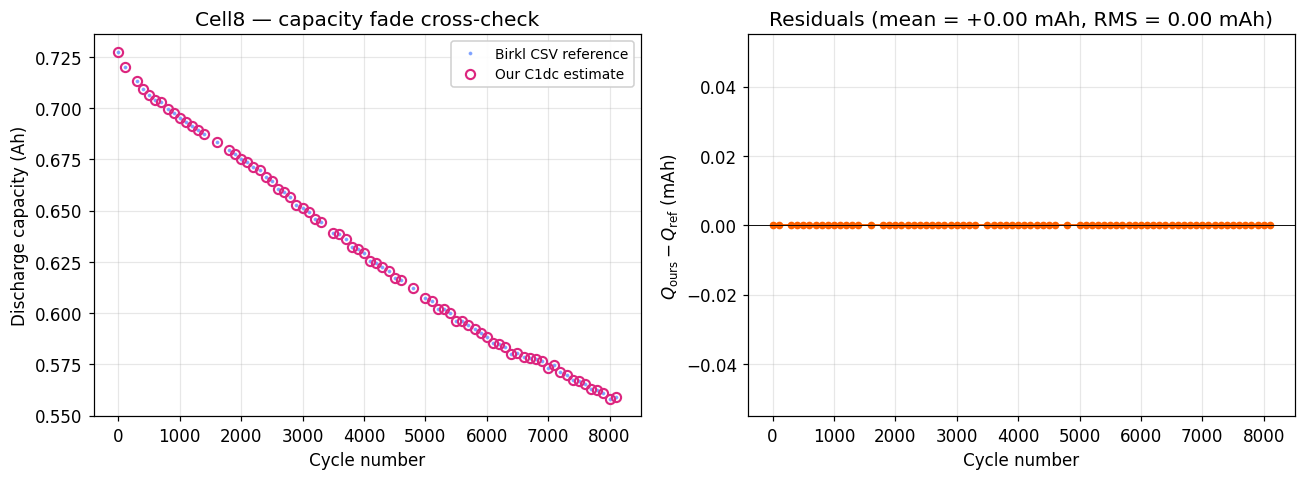

In [ ]:
if cap_csv_path.exists():
    cap_ref = pd.read_csv(cap_csv_path)
    print(f"Reference CSV columns: {list(cap_ref.columns)}")
    print(cap_ref.head().to_string(index=False))

    # Auto-detect cycle and capacity columns by name keywords
    cyc_col = next((c for c in cap_ref.columns if 'cyc' in c.lower()), cap_ref.columns[0])
    cap_col = next((c for c in cap_ref.columns
                    if any(k in c.lower() for k in ('cap', 'ah', 'mah', 'q'))),
                   cap_ref.columns[1])
    print(f"\nUsing  cycle column   : '{cyc_col}'")
    print(f"Using  capacity column: '{cap_col}'")

    ref_cap = pd.to_numeric(cap_ref[cap_col], errors='coerce')
    # Oxford CSV stores discharge capacity as negative numbers (e.g. -727 mAh).
    # Take magnitude first, then convert mAh → Ah if the magnitudes look like mAh
    # (Kokam nominal = 740 mAh ≈ 0.74 Ah, so abs > 5 is the mAh case).
    ref_cap = ref_cap.abs()
    if ref_cap.max() > 5:
        ref_cap = ref_cap / 1000.0
        print("Reference capacity column appeared to be in mAh — converted to Ah.")

    cell8 = cap_df[cap_df['cell_id'] == 'Cell8'].sort_values('cycle_number')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    ax.plot(cap_ref[cyc_col], ref_cap, '.', color=IBM[0],
            label='Birkl CSV reference', markersize=3, alpha=0.7)
    ax.plot(cell8['cycle_number'], cell8['capacity_ah'], 'o',
            color=IBM[2], label='Our C1dc estimate',
            markersize=6, markerfacecolor='none', markeredgewidth=1.4)
    ax.set_xlabel('Cycle number')
    ax.set_ylabel('Discharge capacity (Ah)')
    ax.set_title('Cell8 — capacity fade cross-check')
    ax.legend(loc='best', fontsize=9, framealpha=0.92)

    # Difference at matched cycles (nearest cycle within tolerance)
    ax = axes[1]
    matched_diff = []
    for _, row in cell8.iterrows():
        nearby = cap_ref[np.abs(cap_ref[cyc_col] - row['cycle_number']) <= 1]
        if len(nearby):
            ref_val = ref_cap.loc[nearby.index].mean()
            matched_diff.append((row['cycle_number'],
                                 (row['capacity_ah'] - ref_val) * 1000))  # mAh
    if matched_diff:
        cn, dq = zip(*matched_diff)
        ax.plot(cn, dq, 'o-', color=IBM[3], markersize=4, linewidth=1.2)
        ax.axhline(0, color='black', linewidth=0.6)
        ax.set_xlabel('Cycle number')
        ax.set_ylabel(r'$Q_\mathrm{ours} - Q_\mathrm{ref}$ (mAh)')
        ax.set_title(f'Residuals (mean = {np.mean(dq):+.2f} mAh, '
                     f'RMS = {np.sqrt(np.mean(np.square(dq))):.2f} mAh)')

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'fig_oxford_cell8_capacity_crosscheck.png')
    plt.show()
else:
    print("Capacity_Fade_Cell8.csv not available — cross-check skipped.")

## 6. Pseudo-OCV extraction (C/25 discharge branch)

For each `OCVdc` record we apply the manuscript §3.1 protocol:

1. Voltage range clip $(V_\min, V_\max)$ and rolling-median MAD outlier mask
2. SOC reconstruction from discharge capacity: $\mathrm{SOC} = 1 - (Q_d - Q_{d,\min})/(Q_{d,\max} - Q_{d,\min})$
3. Sort by ascending SOC, deduplicate near-identical SOC samples
4. Savitzky–Golay smoothing (adaptive window, order 3) — applied lightly, since C/25 data is already smooth
5. PCHIP interpolation onto common grid (0.01 → 0.99, 99 points)
6. Refuse extrapolation outside the supported SOC range (mark unsupported grid points as NaN)

In [ ]:
# ─── Reconstruction parameters (Paper 1 protocol) ───
SOC_GRID = np.linspace(0.01, 0.99, 99)
V_MIN, V_MAX = 2.5, 4.3            # Kokam NMC/LCO operating window
MAD_LAMBDA   = 6.0
MEDIAN_WINDOW = 21
SAVGOL_ORDER  = 3
# ────────────────────────────────────────────────────


def clean_voltage_mask(v, v_min=V_MIN, v_max=V_MAX,
                       window=MEDIAN_WINDOW, mad_lambda=MAD_LAMBDA):
    """§3.1.5: range clip + rolling-median MAD outlier mask."""
    v = np.asarray(v, dtype=float).ravel()
    ok = (v >= v_min) & (v <= v_max) & np.isfinite(v)
    if ok.sum() > window:
        med = pd.Series(v).rolling(window, center=True, min_periods=1).median().values
        r = v - med
        mad = np.nanmedian(np.abs(r - np.nanmedian(r))) + 1e-9
        ok &= np.abs(r) <= mad_lambda * mad
    return ok


def reconstruct_soc_discharge(q):
    """§3.1.6: SOC reconstruction from cumulative discharge.

    Canonical, sign-agnostic formulation that works for both:
      - CALCE convention: q goes 0 → +Q_nom (positive, increasing during discharge)
      - Oxford convention: q goes 0 → -Q_nom (negative, decreasing during discharge)

    The cumulative *discharged* charge is Q_d(t) = q(t) - q(0), and:

        SOC(t) = 1 - |Q_d(t)| / |Q_d|_max

    so SOC ≈ 1 at the start of discharge and SOC ≈ 0 at the end, regardless
    of which sign convention the dataset uses.
    """
    q = np.asarray(q, dtype=float).ravel()
    if len(q) < 2 or not np.all(np.isfinite(q[:2])):
        return None
    q_disch = np.abs(q - q[0])
    q_max = np.nanmax(q_disch)
    if not np.isfinite(q_max) or q_max <= 0:
        return None
    return 1.0 - q_disch / q_max


def adaptive_savgol_window(n_samples, target=51, min_window=11):
    """Pick an odd window ≤ target, ≤ n_samples-1, ≥ min_window."""
    w = min(target, n_samples - 1)
    if w % 2 == 0:
        w -= 1
    return w if w >= min_window else 0


def extract_pseudo_ocv(ocvdc):
    """OCVdc record → pseudo-OCV resampled on SOC_GRID (or None if unusable)."""
    if ocvdc is None:
        return None
    v = get_field(ocvdc, 'v')
    q = get_field(ocvdc, 'q')
    if v is None or q is None:
        return None
    v = np.asarray(v, dtype=float).ravel()
    q = np.asarray(q, dtype=float).ravel()
    if len(v) < 50 or len(q) < 50 or len(v) != len(q):
        return None

    # 1. Voltage cleaning
    ok = clean_voltage_mask(v)
    if ok.sum() < 50:
        return None
    v, q = v[ok], q[ok]

    # 2. SOC reconstruction (sign-agnostic: handles Oxford's q ∈ [0, -740 mAh]
    #    convention as well as CALCE's q ∈ [0, +Q_nom] convention)
    soc = reconstruct_soc_discharge(q)
    if soc is None:
        return None

    # 3. Sort ascending SOC, deduplicate
    order = np.argsort(soc)
    soc_s, v_s = soc[order], v[order]
    keep = np.concatenate([[True], np.diff(soc_s) > 1e-6])
    soc_s, v_s = soc_s[keep], v_s[keep]
    if len(soc_s) < 50:
        return None

    # 4. Light Savitzky–Golay smoothing
    w = adaptive_savgol_window(len(v_s))
    if w >= 11:
        try:
            v_s = savgol_filter(v_s, window_length=w, polyorder=SAVGOL_ORDER)
        except Exception:
            pass

    # 5. PCHIP interpolation onto common grid (no extrapolation)
    interp = PchipInterpolator(soc_s, v_s, extrapolate=False)
    v_grid = interp(SOC_GRID)

    if np.isfinite(v_grid).sum() < 50:
        return None
    return v_grid


# ─── Build the long-format pseudo-OCV table ───
ocv_rows = []
skipped = []
for ck in cell_keys:
    cell = raw[ck]
    for cyc_key in cycle_keys(cell):
        cyc = get_field(cell, cyc_key)
        ocvdc = get_field(cyc, 'OCVdc')
        v_grid = extract_pseudo_ocv(ocvdc)
        if v_grid is None:
            skipped.append((ck, cyc_key))
            continue

        soh_match = cap_df[(cap_df['cell_id'] == ck) &
                           (cap_df['cycle_key'] == cyc_key)]
        soh_val = float(soh_match['soh'].iloc[0]) if len(soh_match) else np.nan
        cyc_num = cycle_number(cyc_key)

        for soc_i, v_i in zip(SOC_GRID, v_grid):
            ocv_rows.append({
                'cell_id'      : ck,
                'cycle_key'    : cyc_key,
                'cycle_number' : cyc_num,
                'soh'          : soh_val,
                'soc'          : float(soc_i),
                'voltage'      : float(v_i) if np.isfinite(v_i) else np.nan,
            })

ocv_df = pd.DataFrame(ocv_rows)

n_states_per_cell = ocv_df.groupby('cell_id')['cycle_key'].nunique()
print(f"Extracted pseudo-OCV curves : {n_states_per_cell.sum()} total")
print(f"Avg aging states / cell     : {n_states_per_cell.mean():.1f}")
print(f"Skipped records             : {len(skipped)}")
if skipped:
    print(f"  e.g. {skipped[:5]}")
print(f"NaN voltage fraction        : {ocv_df['voltage'].isna().mean():.3f}")

Extracted pseudo-OCV curves : 519 total
Avg aging states / cell     : 64.9
Skipped records             : 0
NaN voltage fraction        : 0.000


## 7. Write processed outputs

Three files are produced in `processed/`:

| File | Contents |
|------|----------|
| `oxford_capacity_fade.parquet` | per-cell SOH trajectory |
| `oxford_pseudo_ocv.parquet`    | long-format pseudo-OCV(SOC, SOH) table |
| `oxford_summary.csv`           | per-cell counts and ranges for quick inspection |

In [ ]:
cap_out = OUTPUT_DIR / 'oxford_capacity_fade.parquet'
ocv_out = OUTPUT_DIR / 'oxford_pseudo_ocv.parquet'
sum_out = OUTPUT_DIR / 'oxford_summary.csv'

cap_df.to_parquet(cap_out, index=False)
ocv_df.to_parquet(ocv_out, index=False)

summary = (cap_df.groupby('cell_id')
                 .agg(n_aging_states = ('cycle_key',    'count'),
                      first_cycle    = ('cycle_number', 'min'),
                      last_cycle     = ('cycle_number', 'max'),
                      cap_initial_ah = ('capacity_ah',  'first'),
                      cap_final_ah   = ('capacity_ah',  'last'),
                      soh_min        = ('soh',          'min'),
                      soh_max        = ('soh',          'max'))
                 .reset_index())
summary.to_csv(sum_out, index=False)

print(f"  {cap_out.name:38s}  {cap_out.stat().st_size/1024:8.1f} KB")
print(f"  {ocv_out.name:38s}  {ocv_out.stat().st_size/1024:8.1f} KB")
print(f"  {sum_out.name:38s}  {sum_out.stat().st_size/1024:8.1f} KB")
print()
print(summary.to_string(index=False))

  oxford_capacity_fade.parquet                13.8 KB
  oxford_pseudo_ocv.parquet                  515.5 KB
  oxford_summary.csv                           0.7 KB

cell_id  n_aging_states  first_cycle  last_cycle  cap_initial_ah  cap_final_ah  soh_min  soh_max
  Cell1              78            0        8200        0.739111      0.560650 0.757685      1.0
  Cell2              73            0        7700        0.734819      0.544915 0.682393      1.0
  Cell3              76            0        8100        0.735120      0.565857 0.769749      1.0
  Cell4              47            0        5100        0.734076      0.581234 0.791790      1.0
  Cell5              46            0        5000        0.735336      0.456129 0.620300      1.0
  Cell6              46            0        5000        0.732795      0.579023 0.790157      1.0
  Cell7              77            0        8100        0.728746      0.582807 0.799739      1.0
  Cell8              76            0        8100        0.727

## 8. Sanity check plots

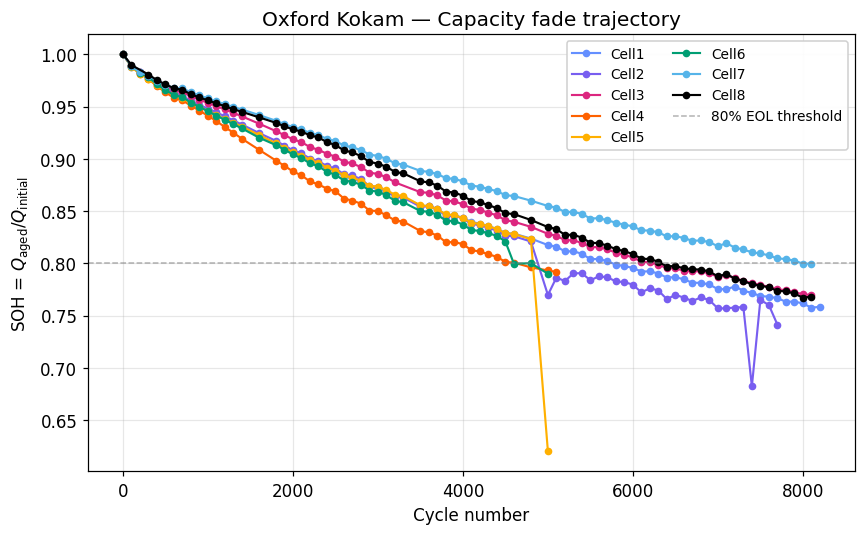

In [ ]:
# ─── Capacity fade trajectory ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for i, (cid, g) in enumerate(cap_df.groupby('cell_id')):
    ax.plot(g['cycle_number'], g['soh'], 'o-',
            color=IBM[i % len(IBM)], label=cid,
            markersize=4, linewidth=1.4)

ax.axhline(0.8, color='gray', linestyle='--', alpha=0.6, linewidth=1,
           label='80% EOL threshold')
ax.set_xlabel('Cycle number')
ax.set_ylabel(r'SOH = $Q_\mathrm{aged} / Q_\mathrm{initial}$')
ax.set_title('Oxford Kokam — Capacity fade trajectory')
ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.92)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig_oxford_soh_vs_cycle.png')
plt.show()

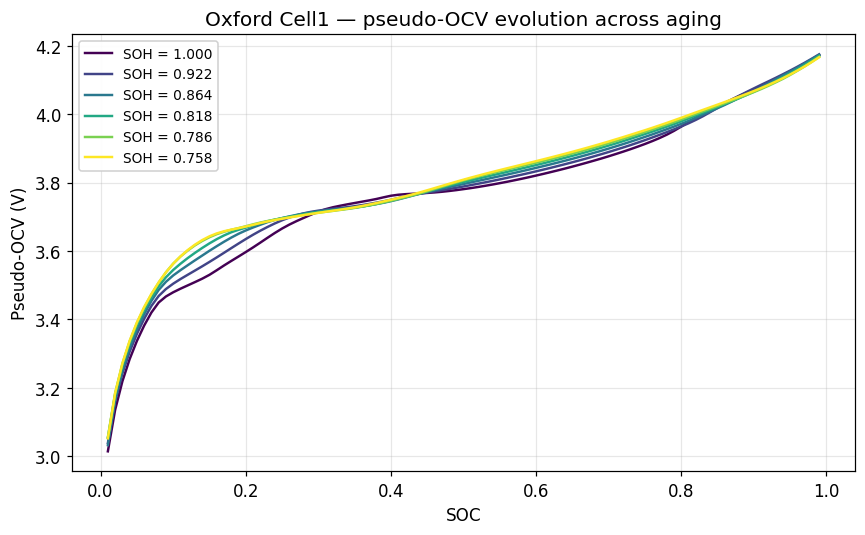

In [ ]:
# ─── Pseudo-OCV evolution with aging — representative cell ─────────────
cell_to_show = cell_keys[0]
sub = ocv_df[ocv_df['cell_id'] == cell_to_show].copy()
soh_levels = sorted(sub['soh'].dropna().unique(), reverse=True)

# Pick ~6 evenly spaced SOH levels for legibility
n_show = min(6, len(soh_levels))
idx = np.linspace(0, len(soh_levels) - 1, n_show).astype(int)
chosen = [soh_levels[i] for i in idx]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis
for j, soh_v in enumerate(chosen):
    s = sub[np.isclose(sub['soh'], soh_v)].sort_values('soc')
    ax.plot(s['soc'], s['voltage'],
            color=cmap(j / max(1, n_show - 1)),
            label=f'SOH = {soh_v:.3f}', linewidth=1.6)

ax.set_xlabel('SOC')
ax.set_ylabel('Pseudo-OCV (V)')
ax.set_title(f'Oxford {cell_to_show} — pseudo-OCV evolution across aging')
ax.legend(loc='best', fontsize=9, framealpha=0.92)
plt.tight_layout()
plt.savefig(FIGURE_DIR / f'fig_oxford_pseudo_ocv_{cell_to_show}.png')
plt.show()

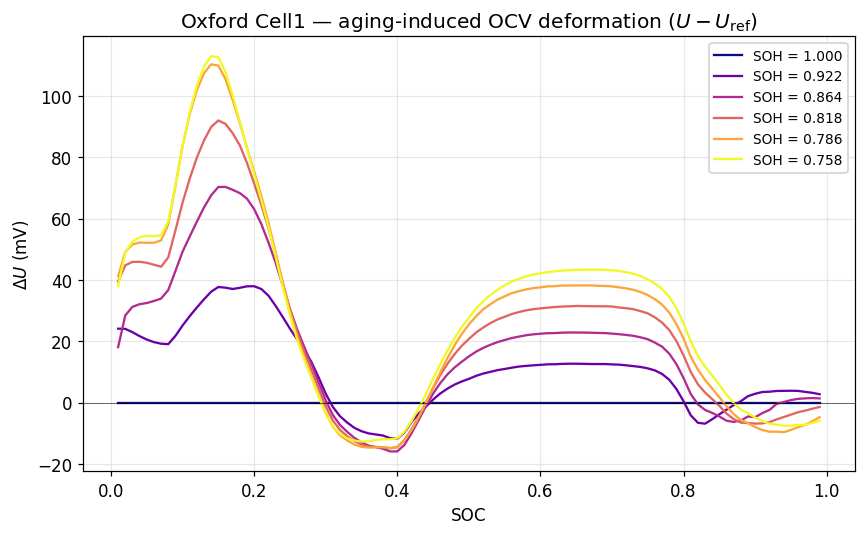

In [ ]:
# ─── ΔU(SOC) deformation preview vs near-pristine reference ──────────────
# Quick look at the §3.3 reference-curve approach before formal §4 results
cell_to_show = cell_keys[0]
sub = ocv_df[ocv_df['cell_id'] == cell_to_show].copy()

# Reference = highest SOH curve for this cell
ref_soh = sub['soh'].max()
ref = (sub[np.isclose(sub['soh'], ref_soh)]
       .sort_values('soc')
       .set_index('soc')['voltage'])

soh_levels = sorted(sub['soh'].dropna().unique(), reverse=True)
n_show = min(6, len(soh_levels))
idx = np.linspace(0, len(soh_levels) - 1, n_show).astype(int)
chosen = [soh_levels[i] for i in idx]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.plasma
for j, soh_v in enumerate(chosen):
    s = (sub[np.isclose(sub['soh'], soh_v)]
         .sort_values('soc')
         .set_index('soc')['voltage'])
    delta = (s - ref).reindex(ref.index)
    ax.plot(delta.index, delta.values * 1000,  # mV
            color=cmap(j / max(1, n_show - 1)),
            label=f'SOH = {soh_v:.3f}', linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.6, alpha=0.6)
ax.set_xlabel('SOC')
ax.set_ylabel(r'$\Delta U$ (mV)')
ax.set_title(f'Oxford {cell_to_show} — aging-induced OCV deformation '
             r'($U - U_\mathrm{ref}$)')
ax.legend(loc='best', fontsize=9, framealpha=0.92)
plt.tight_layout()
plt.savefig(FIGURE_DIR / f'fig_oxford_deltaU_{cell_to_show}.png')
plt.show()

## Next steps

Outputs in `processed/` are ready for §4 Results. Suggested next notebook:

1. Load `oxford_pseudo_ocv.parquet` and the CALCE A123 processed table (from Paper 1)
2. Compute the **dataset-specific reference curves** (manuscript §3.3)
3. Build the deformation profiles $\Delta U(\mathrm{SOC},\mathrm{SOH})$ and the six descriptors (§3.4)
4. Fit **independent** Gaussian Process models per dataset (§3.5) and propagate uncertainty (§3.6)
5. Run the cross-dataset comparison (§3.7) and produce Figures 4.1 – 4.6
6. Cross-check that no descriptor with $\sigma_{\mathrm{GP}} > q_{0.9}$ is claimed as transferable

A note on the §3.4 plateau descriptor: Kokam (NMC/LCO blend) does not have the sharp LFP-style plateau that A123 cells exhibit, so the relative slope-percentile criterion ($\epsilon = q_p(|\partial U / \partial \mathrm{SOC}|)$) will be more meaningful here than an absolute mV / SOC threshold — worth flagging in the §4.3 figure caption to pre-empt reviewers.